# Phase 1
In Anti-Money Laundering (AML), especially in cryptocurrency, criminals don't just steal money and keep it still. They move it through complex webs of accounts to "clean" it (a process called layering). To catch them, we cannot look at transactions in a vacuum; we must look at the relationships between them.

This brings us to Graph Networks. In a graph:
- Nodes are entities (in our case, Bitcoin transactions).
- Edges are the connections between them (the flow of Bitcoin from one transaction to the next).
The goal of this phase is to built a model that catches illicit transactions not just based on the transaction's own features, but based on who it interacts with in the network.

In [18]:
import pandas as pd
from pathlib import Path

The Elliptic dataset is the world's largest labeled dataset of cryptocurrency transactions. It contains over 200,000 Bitcoin transactions.
- Some are labeled as "illicit" (tied to scams, malware, terrorist organizations, etc.).
- Some are labeled as "licit" (exchanges, wallet providers, miners).
- The rest are "unknown.

In [3]:
import kaggle

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


NameError: name 'exit' is not defined

In [ ]:
# Download the dataset using Kaggle API with mac
!kaggle datasets download ellipticco/elliptic-data-set

Dataset URL: https://www.kaggle.com/datasets/ellipticco/elliptic-data-set
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100%|████████████████████████████████████████| 146M/146M [00:09<00:00, 17.0MB/s]



### Wrangling and exploration

In [22]:
#labels
# unknown, 2 (licit), and 1 (illicit).
df_classes = pd.read_csv(Path("elliptic_bitcoin_dataset") / "elliptic_txs_classes.csv")
# two columns of source and destination
df_edgelist = pd.read_csv(Path("elliptic_bitcoin_dataset") / "elliptic_txs_edgelist.csv")
# 165 anonymised mathematical features of every transaction, and a time step from 1 to 49 representing two week intervals. no column names for the features file, so we set header=None
df_features = pd.read_csv(Path("elliptic_bitcoin_dataset") / "elliptic_txs_features.csv", header=None)

print("Classes Overview")
print(df_classes.head())
print("\nClass distribution")
print(df_classes["class"].value_counts())


Classes Overview
        txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown

Class distribution
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


**Observation:** 
77% of our data (157,205 transactions) is "unknown". This reflects the harsh reality of AML: investigators simply don't have the time to investigate and label every single Bitcoin transaction. We only know the true labels for a small fraction of the network. This pushes us into the realm of Semi-Supervised Learning or Node Classification.

For now, to train our initial models, we will only use the transactions we know the answers to (the 1s and 2s). Later, we can use the graph structure to let the "bad" reputation of known illicit nodes bleed over into the "unknown" nodes they interact with.

In [23]:
# merge data labels (df_classes) and our math features (df_features)
# standard ML conventions: unknown -> -1, licit -> 0, ilicit -> 1
class_mapping = {'unknown': -1, '1': 1, '2': 0}
df_classes['class'] = df_classes['class'].map(class_mapping)

# 2. Prepare the features dataframe for merging
# In df_features, column 0 is the txId, column 1 is the time step. 
# We need to name column 0 'txId' so pandas knows how to match the two tables.
print(df_features.head())
df_features = df_features.rename(columns={0: 'txId', 1: 'time_step'})
print(df_features.head())

         0    1         2         3         4          5         6    \
0  230425980    1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458    1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460    1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397    1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314    1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

        7          8         9    ...       157       158       159       160  \
0 -0.113002  -0.061584 -0.162097  ... -0.562153 -0.600999  1.461330  1.461369   
1 -0.113002  -0.061584 -0.162112  ...  0.947382  0.673103 -0.979074 -0.978556   
2 -0.113002  -0.061584 -0.162749  ...  0.670883  0.439728 -0.979074 -0.978556   
3  9.782742  12.414558 -0.163645  ... -0.577099 -0.613614  0.241128  0.241406   
4  1.312656  -0.061584 -0.163523  ... -0.511871 -0.400422  0.517257  0.579382   

        161       162       163       164       165       166  
0  0.018279 -0.0

In [24]:
df = pd.merge(df_classes, df_features, on='txId')
print("Merged dataset shape:", df.shape)
print("Preview of the first 5 columns:")
print(df.iloc[:5, :5])

Merged dataset shape: (203769, 168)
Preview of the first 5 columns:
        txId  class  time_step         2         3
0  230425980     -1          1 -0.171469 -0.184668
1    5530458     -1          1 -0.171484 -0.184668
2  232022460     -1          1 -0.172107 -0.184668
3  232438397      0          1  0.163054  1.963790
4  230460314     -1          1  1.011523 -0.081127


Each time_step represents roughly a two-week period.
- time_step 1 contains all the transactions from the first two weeks of their data collection.
- time_step 2 contains transactions from the next two weeks... all the way up to time_step 49. <br>

If we randomly shuffle the Elliptic Data Set, we fall into a massive trap called Data Leakage (specifically, "look-ahead bias").

### Building a standard model as a baseline

We will build a simple random forest model, it is essentially a voting committee made up of hundreds of individual Decision Trees. By extracting just one of those trees, we can visualize the exact mathematical flowchart it built to separate the money launderers from the normal users.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Filter out the 'unknown' transactions (-1) for our baseline
df_labeled = df[df['class'] != -1]

# 2. Temporal Split (Train on past, Test on future) - avoiding look ahead bias (rather than an 80/20 random split)
train_df = df_labeled[df_labeled['time_step'] <= 34]
test_df = df_labeled[df_labeled['time_step'] > 34]

# 3. Separate features (X) and labels (y)
# We drop 'txId', 'class', and 'time_step' from our features because they aren't math features
cols_to_drop = ['txId', 'class', 'time_step']

X_train = train_df.drop(columns=cols_to_drop)
y_train = train_df['class']

X_test = test_df.drop(columns=cols_to_drop)
y_test = test_df['class']

print(f"Training on {len(X_train)} transactions, testing on {len(X_test)} transactions.")

# 4. Train a Baseline Random Forest
print("Training Baseline Random Forest...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_baseline.fit(X_train, y_train)

# 5. Evaluate
y_pred = rf_baseline.predict(X_test)
print("\n--- Baseline Model Report ---")
print(classification_report(y_test, y_pred))

Training on 29894 transactions, testing on 16670 transactions.
Training Baseline Random Forest...

--- Baseline Model Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15587
           1       0.99      0.68      0.81      1083

    accuracy                           0.98     16670
   macro avg       0.99      0.84      0.90     16670
weighted avg       0.98      0.98      0.98     16670



Interpreting the classification report:
- Support (1083): There were exactly 1,083 actual illicit transactions hidden in your test set.
- **Precision** (0.98): This is spectacular. It means that when your baseline model flags a transaction as money laundering, it is correct 98% of the time. The false alarm rate is incredibly low.
- **Recall** (0.68): Here is the vulnerability. Out of the 1,083 actual illicit transactions, your model only found 68% of them. This means roughly 32% of the money laundering activity completely bypassed your model.
- **F1-Score (0.81)**: The harmonic mean balancing your precision and recall.

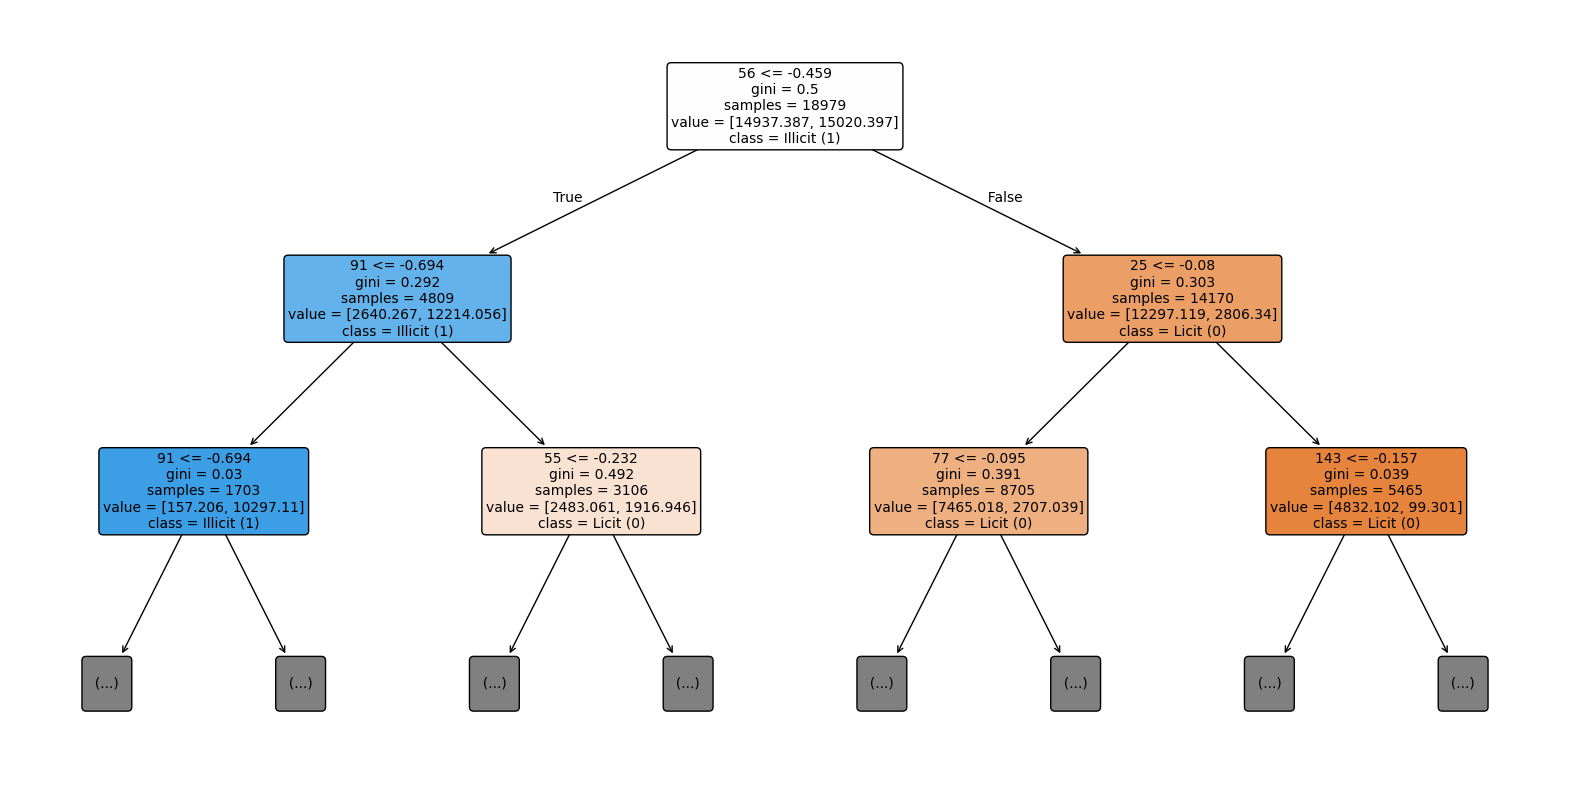

In [26]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Extract the very first tree from our forest
single_tree = rf_baseline.estimators_[0]

# 2. Set up the plot size
plt.figure(figsize=(20, 10))

# 3. Plot the tree! (max_depth=2 keeps it readable)
plot_tree(
    single_tree, 
    max_depth=2, 
    feature_names=X_train.columns.tolist(), 
    class_names=['Licit (0)', 'Illicit (1)'], 
    filled=True, 
    rounded=True,
    fontsize=10
)

plt.show()

Intepreting the confusion matrix and the tree diagram:
- Top box -> The tree determined that "Feature 56" is the most valuable piece of information for its first question. If a transaction's value for Feature 56 is less than or equal to -0.459, the transaction goes down the left path (True). If it is greater, it goes down the right path (False).
    - A Gini score of 0.5 means the data in this box is perfectly mixed between good and bad transactions. As you move further down the tree, the goal is for the Gini score to drop closer to 0 (pure).
    - Samples means 18,979 transactions from your training set passed through this specific node.
    - class = Illicit (1): If the tree was forced to make a final decision right here, it would guess "Illicit" because the weighted value for class 1 is slightly higher.
    - 'value' is the weighted count of Licit (Class 0) vs. Illicit (Class 1) transactions in this box. Because we used class_weight='balanced', the model mathematically boosted the "weight" of the illicit cases so they have an equal voice.
        - Weighted vs Unweighted - Unweighted every person gets 1 vote. Weighted (class_weight='balanced') the smaller class of values has equal voting power (100 ppl in group A x 9 = 900 vs 900 ppl in group B x 1 = 900)
        - class_weight='balanced' tells the algorithm to automatically calculate these multipliers. Because Illicit transactions are rare, the model assigns them a high weight (e.g., each Illicit transaction counts as 10). Because Licit transactions are common, they get a low weight (e.g., each counts as 1).
- Second layer
    - The data is split into smaller groups but the total values add up to actually be the same across each level.

The significance of the **value**/**voting power**
- As you move further down the tree, the values get smaller and smaller because the buckets of data are getting smaller and smaller.
    - The Left box (Blue) caught the vast majority of the Illicit transactions (12,214) and very few Licit ones (2,640). It successfully isolated a lot of bad guys!
    - The Right box (Orange) caught the vast majority of the Licit transactions (12,297) and very few Illicit ones (2,806).
- Machine learning models only have one goal: to get the highest "accuracy" score possible. If you have 99 licit and 1 illicit, the model will identify that the best way forward is just to always guess licit for the highest accuracy.
- class_weight='balanced' artificially balances the scales.
- If the tree tries to use its old cheat code and guesses "Licit" for everything, it gets heavily penalized. It loses 99 points for missing that one bad guy.
- The tree is forced to actually do its job. It is forced to hunt through all 165 features to find a mathematical rule (like your Feature 56 <= -0.459) that successfully separates that heavy, highly penalized bad guy from the rest of the group.

Why the penalty matters
- In Supervised Learning, the algorithm is driven by something called a Loss Function.
    - The model takes a blind guess at the data. -> The Loss Function steps in and grades the test. If the model guessed wrong the Loss Function slaps the model with a massive penalty (high Loss). The model looks at that high penalty and tweaks and tests and It repeats this thousands of times, constantly adjusting its rules to minimize the Loss.
- Gini is this model's loss function
    - A Gini of 0.5 means maximum chaos (a 50/50 split of good and bad guys). The tree hates this.
    - A Gini of 0.0 means perfect purity (a box with only bad guys or only good guys).
- When we talked about the "lazy machine" and adding class_weight='balanced', we weren't offering the model a 99-point reward for finding the money launderer.
    - We were telling the Loss Function to issue a 9x Penalty if the missclassified someone from group A in to group B, which it will not accept

### Building a graph 'feature' for model training

We will build a mathematical web (a Graph) and extract Network Features.

Specifically, we are going to calculate the In-Degree and Out-Degree for every single transaction:
- In-Degree: How many previous transactions sent Bitcoin into this transaction? (Consolidation of stolen funds).
- Out-Degree: How many future transactions did this transaction send Bitcoin out to? (Smurfing/layering the money to hide it).

In [31]:
import networkx as nx

print("Building the money flow graph... this might take a few seconds.")

# 1. Create an empty Directed Graph (because money flows in a specific direction)
G = nx.DiGraph()

# 2. Add all the edges (the flow of money) from our df_edgelist table
# df_edgelist has 'txId1' (source) and 'txId2' (destination)
edges = list(zip(df_edgelist['txId1'], df_edgelist['txId2']))
G.add_edges_from(edges)

print(f"Graph built! It contains {G.number_of_nodes()} unique transactions and {G.number_of_edges()} connections.")

# 3. Calculate the Network Features
print("Calculating In-Degree and Out-Degree...")
in_degree_dict = dict(G.in_degree())
out_degree_dict = dict(G.out_degree())

# 4. Map these new features back to our main 'df' dataframe
# If a transaction doesn't have any incoming/outgoing edges in our dataset, it gets a 0
df['in_degree'] = df['txId'].map(in_degree_dict).fillna(0)
df['out_degree'] = df['txId'].map(out_degree_dict).fillna(0)

print("\nSuccess! New network features added. Here is a peek:")
print(df[['txId', 'class', 'in_degree', 'out_degree']].head(10))

Building the money flow graph... this might take a few seconds.
Graph built! It contains 203769 unique transactions and 234355 connections.
Calculating In-Degree and Out-Degree...

Success! New network features added. Here is a peek:
        txId  class  in_degree  out_degree
0  230425980     -1          1           1
1    5530458     -1          1           1
2  232022460     -1          1           2
3  232438397      0        160           1
4  230460314     -1          2           8
5  230459870     -1          4           6
6  230333930     -1          0           2
7  230595899     -1          2           1
8  232013274     -1          0           2
9  232029206      0         59           1


Generallly a **large out degree** is often seen as a sign of laundering. It is often called Layering or Structuring (often colloquially called "Smurfing").

Criminals know that moving $10,000,000 in a single massive transaction will immediately trigger alarms at any exchange or bank. So they "split up" the large sum into thousands of tiny, seemingly harmless transactions (high Out-Degree). They send these to hundreds of different wallets, bounce them around, and eventually reconsolidate them (high In-Degree) at a final destination where they cash out. In crypto this is called a "peel chain".

Now we can retrain the exact same Random Forest model, using the exact same temporal split (Time Steps 1-34 for training, 35-49 for testing) -> only difference is that our Features (X) will now include our two new columns: in_degree and out_degree.

In [34]:
# 1. Filter out the 'unknown' transactions (-1) again
df_labeled = df[df['class'] != -1]

# 2. Temporal Split (Train <= 34, Test > 34)
train_df = df_labeled[df_labeled['time_step'] <= 34]
test_df = df_labeled[df_labeled['time_step'] > 34]

# 3. Separate features (X) and labels (y)
cols_to_drop = ['txId', 'class', 'time_step']

# Our X_train and X_test now naturally include the new 'in_degree' and 'out_degree' columns!
X_train_net = train_df.drop(columns=cols_to_drop)
y_train_net = train_df['class']

X_test_net = test_df.drop(columns=cols_to_drop)
y_test_net = test_df['class']

X_train_net.columns = X_train_net.columns.astype(str)
X_test_net.columns = X_test_net.columns.astype(str)

# 4. Train the New Random Forest
print("Training Random Forest with Network Features...")
rf_network = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_network.fit(X_train_net, y_train_net)

# 5. Evaluate
y_pred_net = rf_network.predict(X_test_net)
print("\n--- Model with Network Features Report ---")
print(classification_report(y_test_net, y_pred_net))

Training Random Forest with Network Features...

--- Model with Network Features Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15587
           1       0.99      0.70      0.82      1083

    accuracy                           0.98     16670
   macro avg       0.98      0.85      0.90     16670
weighted avg       0.98      0.98      0.98     16670



Comparing the classification report:
- **Support** (same 1083): There were exactly 1,083 actual illicit transactions hidden in your test set.
- **Precision** (0.99) - same as before, when identifying the a illicit transaction its equally as accurate
- **Recall** (0.7 v 0.68):  Out of the 1,083 actual illicit transactions, the new model found 70% of them
- **F1-Score (0.98)**: The harmonic mean balancing your precision and recall.

In [35]:
import joblib

# 1. Save the model we just trained
joblib.dump(rf_network, 'rf_network_model.joblib')

# 2. Save the exact test dataset we used (so we can explain these specific transactions)
# We save it as a CSV so it's easy to load in the next notebook
X_test_net.to_csv('X_test_network.csv', index=False)

print("Model and Test Data successfully saved! You are ready to open the new notebook.")

Model and Test Data successfully saved! You are ready to open the new notebook.
